**0. Imports:**

In [7]:
import earthcarekit as eck
import xarray as xr
xr.set_options(display_expand_data_vars=True, display_max_rows=500, display_max_items=10000)
import re
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d 
import sys
import shlex
import shutil
from datetime import date

**0b. Remote ZIP Helpers (check_run + my_subprocess)**


In [8]:

# --- Remote ZIP ingest helpers ---
# This block replaces the external check_run.py flow directly inside the notebook.
# Workflow: discover remote ZIPs -> copy 1 ZIP locally -> unzip -> process .h5 -> delete local temp data.

# Import command runner from my_subprocess.py
MY_SUBPROCESS_DIR = Path("/Users/tobiasraucher/Python/OneDrive_1_24-2-2026")
if str(MY_SUBPROCESS_DIR) not in sys.path:
    sys.path.insert(0, str(MY_SUBPROCESS_DIR))

from my_subprocess import run_shell_cmd_and_communicate, print_shell_output


def _to_date(v):
    """Normalize date/datetime/string to a date object."""
    if isinstance(v, datetime):
        return v.date()
    if isinstance(v, date):
        return v
    if isinstance(v, str):
        return datetime.strptime(v, "%Y-%m-%d").date()
    raise TypeError(f"Unsupported date type: {type(v)}")


def run_cmd_checked(cmd: str, verbose: bool = False):
    """Run shell command via my_subprocess; raise if command fails."""
    lines_out, lines_err, rc = run_shell_cmd_and_communicate(cmd, verbose=verbose)
    if rc != 0:
        print_shell_output(lines_out, lines_err, prefix="[shell] ")
        raise RuntimeError(f"Command failed (exit {rc}): {cmd}")
    return lines_out, lines_err


def discover_remote_zip_files(remote_product_root, start_date, end_date):
    """Discover .ZIP/.zip files in YYYY/MM/DD folders in [start_date, end_date]."""
    root = Path(remote_product_root)
    start = _to_date(start_date)
    end = _to_date(end_date)
    if end < start:
        raise ValueError("end_date must be >= start_date")

    zips = []
    day = start
    while day <= end:
        day_dir = root / day.strftime("%Y") / day.strftime("%m") / day.strftime("%d")
        if day_dir.exists():
            zips.extend(sorted(day_dir.glob("*.ZIP")))
            zips.extend(sorted(day_dir.glob("*.zip")))
        day += timedelta(days=1)

    # Keep deterministic order and remove duplicates if both patterns matched same file.
    return sorted(dict.fromkeys(zips))


def stage_zip_and_extract(src_zip: Path, local_stage_root: Path):
    """
    Copy one remote ZIP to local stage, extract it, and return extracted .h5 files.
    """
    local_stage_root.mkdir(parents=True, exist_ok=True)
    local_zip = local_stage_root / src_zip.name
    extract_dir = local_stage_root / src_zip.stem

    # Ensure clean stage for this ZIP.
    if local_zip.exists():
        local_zip.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    run_cmd_checked(f"cp {shlex.quote(str(src_zip))} {shlex.quote(str(local_zip))}")
    run_cmd_checked(f"unzip -oq {shlex.quote(str(local_zip))} -d {shlex.quote(str(extract_dir))}")

    h5_files = sorted(extract_dir.rglob("*.h5"))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 after extracting: {src_zip}")

    return local_zip, extract_dir, h5_files


def cleanup_staged_data(local_zip: Path | None, extract_dir: Path | None):
    """Delete only local staged ZIP + extracted folder (never remote source files)."""
    if extract_dir is not None and extract_dir.exists():
        shutil.rmtree(extract_dir)
    if local_zip is not None and local_zip.exists():
        local_zip.unlink()


**1. Config**

In [9]:

# Input data (remote archive mounted on work PC)
# Current run: process ATL_TC__2A directly.
REMOTE_PRODUCT_ROOT = Path("/net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A")

# Local staging folder for temporary ZIP/extracted data (safe to clean)
LOCAL_STAGE_ROOT = Path("/Users/tobiasraucher/Python/KNMI/EC_Data/tmp_stage_icecloud")
LOCAL_STAGE_ROOT.mkdir(parents=True, exist_ok=True)

START_DATE = "2025-12-01"   # YYYY-MM-DD
END_DATE   = "2025-12-31"   # YYYY-MM-DD

# Output
OUTPUT_ROOT = Path("/Users/tobiasraucher/Python/KNMI/Plot software/ectools/Final_Heatmap_IceClouds/output")

# Classification name
CLASS_VAR = "classification"

# Target class (3 = Ice Cloud)
TARGET_CLASS = 3

# Coordinate variable names
LAT = "latitude"
LON = "longitude"

# Quality filter settings (optional)
# USE_QC_FILTER = True
# QC_VAR = "quality_status"
# QC_THRESHOLD = 2            # keep pixels where qc < 2

# 2D heatmap resolution in degrees
GRID_RES_DEG = 1.0

# Vertical harmonization settings
HEIGHT_VAR = "height"
USE_VERTICAL_INTERP = True
TARGET_H_FROM_FIRST_FILE = True

# Hide noisy cells with too few samples
MIN_SAMPLES_PER_CELL = 10

# Derived run metadata
start_dt = datetime.strptime(START_DATE, "%Y-%m-%d").date()
end_dt = datetime.strptime(END_DATE, "%Y-%m-%d").date()
if end_dt < start_dt:
    raise ValueError("END_DATE must be >= START_DATE")

if not REMOTE_PRODUCT_ROOT.exists():
    raise FileNotFoundError(f"Remote path not mounted/reachable: {REMOTE_PRODUCT_ROOT}")

# Build a consistent run label used in filenames
RUN_LABEL = f"icecloud_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}_{GRID_RES_DEG:.1f}deg"

# Output filenames
OUTFILE_COUNTS = OUTPUT_ROOT / f"{RUN_LABEL}_counts.nc"        # ice_count + total_count
OUTFILE_OCC    = OUTPUT_ROOT / f"{RUN_LABEL}_occurrence.nc"    # occurrence map

print("Config loaded")
print("REMOTE_PRODUCT_ROOT:", REMOTE_PRODUCT_ROOT)
print("LOCAL_STAGE_ROOT:", LOCAL_STAGE_ROOT)
print("DATE RANGE:", start_dt, "to", end_dt)
print("TARGET_CLASS:", TARGET_CLASS, "| CLASS_VAR:", CLASS_VAR)
print("OUTFILE_COUNTS:", OUTFILE_COUNTS)
print("OUTFILE_OCC:", OUTFILE_OCC)


FileNotFoundError: Remote path not mounted/reachable: /net/pc230016/nobackup_1/users/zadelhof/EarthCARE_DATA/L2/ATL_TC__2A

**2. File Discovery**

In [4]:

# Discover remote ZIP files in YYYY/MM/DD folders
zip_paths = discover_remote_zip_files(REMOTE_PRODUCT_ROOT, start_dt, end_dt)

print(f"Discovered {len(zip_paths)} ZIP files")
print(f"Range: {start_dt} -> {end_dt}")
if zip_paths:
    print("First ZIPs:")
    for p in zip_paths[:5]:
        print(" -", p)
    if len(zip_paths) > 5:
        print(f" ... and {len(zip_paths)-5} more")

# Fail fast if date/path config is wrong
if len(zip_paths) == 0:
    raise FileNotFoundError("No ZIP files found for this date range/product.")


Discovered 17 .h5 files
Range: 2025-12-01 -> 2027-12-31
First files:
 - /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T174650Z_20260216T200500Z_09784A/ECA_EXBC_ATL_TC__2A_20260216T174650Z_20260216T200500Z_09784A.h5
 - /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T175825Z_20260216T200649Z_09784B/ECA_EXBC_ATL_TC__2A_20260216T175825Z_20260216T200649Z_09784B.h5
 - /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T181012Z_20260216T200440Z_09784C/ECA_EXBC_ATL_TC__2A_20260216T181012Z_20260216T200440Z_09784C.h5
 - /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T182116Z_20260216T200443Z_09784D/ECA_EXBC_ATL_TC__2A_20260216T182116Z_20260216T200443Z_09784D.h5
 - /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T183302Z_20260216T

**3. Single-File Inspection**

In [5]:

# Stage one ZIP locally for inspection, then clean up local temporary data
local_zip = None
extract_dir = None

try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    fp0 = str(staged_h5[0])
    print("Inspecting staged file:", fp0)

    with eck.read_product(fp0) as ds0:
        # Basic overview
        print("\nDataset summary:")
        print("height shape:", ds0[HEIGHT_VAR].shape)
        display(ds0)

        # Show dimension sizes
        print("\nDimensions:")
        for k, v in ds0.sizes.items():
            print(f" - {k}: {v}")

        # List available data variables in this product
        print("\nData variables:")
        for name in ds0.data_vars:
            print(" -", name)

        # Check the key variables
        required_vars = [CLASS_VAR, LAT, HEIGHT_VAR, LON]
        # if USE_QC_FILTER:
        #     required_vars.append(QC_VAR)

        print("\nRequired variable check:")
        for v in required_vars:
            print(f" - {v}: {'OK' if v in ds0.data_vars else 'MISSING'}")

        # Show target classification definition nicely
        print("\nClassification metadata:")
        print("long_name:", ds0[CLASS_VAR].attrs.get("long_name", "n/a"))
        definition = ds0[CLASS_VAR].attrs.get("definition", "n/a")
        print("definition:")
        print(definition)

        # Parse code -> meaning from the definition text
        code_to_meaning = {}
        for line in definition.splitlines():
            line = line.strip()
            if not line:
                continue
            m = re.match(r"^([-\d:]+)\s*:\s*(.+)$", line)
            if not m:
                continue

            code_token, meaning = m.groups()
            if code_token.lstrip("-").isdigit():
                code_to_meaning[int(code_token)] = meaning
            elif ":" in code_token:
                a, b = code_token.split(":", 1)
                if a.lstrip("-").isdigit() and b.lstrip("-").isdigit():
                    a, b = int(a), int(b)
                    step = 1 if b >= a else -1
                    for c in range(a, b + step, step):
                        code_to_meaning[c] = meaning

        # Count classes present in this file
        cls_vals = ds0[CLASS_VAR].values
        unique_codes = (
            pd.Series(cls_vals.ravel())
            .dropna()
            .astype(int)
            .value_counts()
            .sort_index()
            .rename("count")
            .reset_index()
            .rename(columns={"index": "target_class_code"})
        )
        unique_codes.insert(
            0,
            "target_class_name",
            unique_codes["target_class_code"].map(code_to_meaning).fillna("Unknown"),
        )
        print("\nUnique class codes in this file (name | code | count):")
        display(unique_codes)
finally:
    cleanup_staged_data(local_zip, extract_dir)


Inspecting: /Users/tobiasraucher/Python/KNMI/EC_Data/level2a/ATL_TC__2A/2026/02/16/BC/ECA_EXBC_ATL_TC__2A_20260216T174650Z_20260216T200500Z_09784A/ECA_EXBC_ATL_TC__2A_20260216T174650Z_20260216T200500Z_09784A.h5

Dataset summary:
height shape: (4868, 242)


<xarray.Dataset> Size: 58MB
Dimensions:                                                 (along_track: 4868,
                                                             vertical: 242,
                                                             class: 7)
Dimensions without coordinates: along_track, vertical, class
Data variables:
    filename                                                <U60 240B ...
    file_type                                               <U10 40B ...
    frame_id                                                <U1 4B 'A'
    orbit_number                                            uint32 4B 9784
    orbit_and_frame                                         <U6 24B '09784A'
    baseline                                                <U2 8B 'BC'
    sensing_start_time                                      datetime64[ns] 8B ...
    processing_start_time                                   datetime64[ns] 8B ...
    trim_index_offset                                       int64 8B 99
    medium_resolution_number_of_joint_standard_grid_pixels  int16 2B 11
    low_resolution_number_of_joint_standard_grid_pixels     int16 2B 101
    joint_standard_grid_index                               (along_track) int32 19kB ...
    latitude                                                (along_track) float64 39kB ...
    longitude                                               (along_track) float64 39kB ...
    time                                                    (along_track) datetime64[ns] 39kB ...
    height                                                  (along_track, vertical) float32 5MB ...
    range                                                   (along_track, vertical) float32 5MB ...
    viewing_elevation_angle                                 (along_track) float32 19kB ...
    elevation                                               (along_track) float32 19kB ...
    tropopause_height                                       (along_track) float32 19kB ...
    geoid_offset                                            (along_track) float32 19kB ...
    simple_classification                                   (along_track, vertical) int8 1MB ...
    mie_detection_status                                    (along_track, vertical) int8 1MB ...
    rayleigh_detection_status                               (along_track, vertical) int8 1MB ...
    extended_data_quality_status                            (along_track, vertical) int8 1MB ...
    quality_status                                          (along_track, vertical) int8 1MB ...
    aerosol_classes                                         (class) |S32 224B ...
    aerosol_classification_prob                             (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_medium_resolution           (along_track, vertical, class) int8 8MB ...
    aerosol_classification_prob_low_resolution              (along_track, vertical, class) int8 8MB ...
    classification                                          (along_track, vertical) int8 1MB ...
    classification_medium_resolution                        (along_track, vertical) int8 1MB ...
    classification_low_resolution                           (along_track, vertical) int8 1MB ...
    temperature                                             (along_track, vertical) float32 5MB ...
    pressure                                                (along_track, vertical) float32 5MB ...
    relative_humidity                                       (along_track, vertical) float32 5MB ...


Dimensions:
 - along_track: 4868
 - vertical: 242
 - class: 7

Data variables:
 - filename
 - file_type
 - frame_id
 - orbit_number
 - orbit_and_frame
 - baseline
 - sensing_start_time
 - processing_start_time
 - trim_index_offset
 - medium_resolution_number_of_joint_standard_grid_pixels
 - low_resolution_number_of_joint_standard_grid_pixels
 - joint_standard_grid_index
 - latitude
 - longitude
 - time
 - height
 - range
 - viewing_elevation_angle
 - elevation
 - tropopause_height
 - geoid_offset
 - simple_classification
 - mie_detection_status
 - rayleigh_detection_status
 - extended_data_quality_status
 - quality_status
 - aerosol_classes
 - aerosol_classification_prob
 - aerosol_classification_prob_medium_resolution
 - aerosol_classification_prob_low_resolution
 - classification
 - classification_medium_resolution
 - classification_low_resolution
 - temperature
 - pressure
 - relative_humidity

Required variable check:
 - classification: OK
 - latitude: OK
 - height: OK
 - longitud

,target_class_name,target_class_code,count
0,Surface or sub-surface,-2,39870
1,Noise in both Mie and Ray Channels,-1,171931
2,Clear,0,649803
3,(Warm) Liquid Cloud,1,5623
4,(Supercooled) Liquid Cloud,2,3986
5,Ice Cloud,3,135765
6,Dust,10,588
7,Sea_salt,11,27948
8,Continental_Pollution,12,16089
9,Smoke,13,22998


**4. Grid Setup**

In [6]:

# Global regular lat/lon bins
lat_bins = np.arange(-90.0, 90.0 + GRID_RES_DEG, GRID_RES_DEG)
lon_bins = np.arange(-180.0, 180.0 + GRID_RES_DEG, GRID_RES_DEG)

# Bin centers
lat_centers = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lon_centers = 0.5 * (lon_bins[:-1] + lon_bins[1:])

n_lat = len(lat_centers)
n_lon = len(lon_centers)

# Build common vertical grid from first staged file
local_zip = None
extract_dir = None
try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    with eck.read_product(str(staged_h5[0])) as ds0:
        target_h = ds0[HEIGHT_VAR].values[0, :]
finally:
    cleanup_staged_data(local_zip, extract_dir)

# take height levels from first profile of first file
n_height = target_h.size

# 3D accumulators: (lat, lon, height)
total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

print("Grid ready")
print("GRID_RES_DEG:", GRID_RES_DEG)
print("Shape (lat, lon, height):", total_count_3d.shape)
print("n_lat, n_lon, n_height:", n_lat, n_lon, n_height)
print("Latitude centers:", lat_centers[0], "...", lat_centers[-1])
print("Longitude centers:", lon_centers[0], "...", lon_centers[-1])
print("Target height range:", float(np.nanmin(target_h)), "...", float(np.nanmax(target_h)))

### QUALITY CHECKS ###
assert total_count_3d.shape == ice_count_3d.shape
assert total_count_3d.shape == (n_lat, n_lon, n_height)

assert np.isclose(lat_bins[1] - lat_bins[0], GRID_RES_DEG)
assert np.isclose(lon_bins[1] - lon_bins[0], GRID_RES_DEG)

assert target_h.ndim == 1
assert len(target_h) == n_height


Grid ready
GRID_RES_DEG: 1.0
Shape (lat, lon, height): (180, 360, 242)
n_lat, n_lon, n_height: 180 360 242
Latitude centers: -89.5 ... 89.5
Longitude centers: -179.5 ... 179.5
Target height range: -471.6175537109375 ... 39843.11328125


**5. One-File Accumulator**

In [7]:

"""
Process one ATL_TC file and accumulate counts on a (lat, lon, height) grid.

Returns:

    total_hist_3d : np.ndarray
        Number of valid pixels per grid cell.
    ice_hist_3d : np.ndarray
        Number of ice-cloud pixels per grid cell.
"""

def accumulate_one_file(fp, lat_bins, lon_bins, target_h):
    with eck.read_product(str(fp)) as ds:
        cls = ds[CLASS_VAR].values.astype(float)      # (along_track, vertical)
        h = ds[HEIGHT_VAR].values                     # (along_track, vertical)
        lat = ds[LAT].values                      # (along_track,)
        lon = ds[LON].values                      # (along_track,)
        # qc = ds[QC_VAR].values if USE_QC_FILTER else None

        n_obs = cls.shape[0]
        n_height = target_h.size

        # Interpolated ice mask for each profile on common vertical grid
        ice_interp = np.full((n_obs, n_height), np.nan, dtype=float)

        # Process each along-track profile independently
        for i in range(n_obs):
            h_i = h[i, :]
            cls_i = cls[i, :]

            # Keep only finite samples
            valid = np.isfinite(h_i) & np.isfinite(cls_i)
            # if USE_QC_FILTER:
            #     valid &= (qc[i, :] < QC_THRESHOLD)

            # Need at least 2 points for interpolation
            if np.sum(valid) < 2:
                continue

            # Convert class code to binary ice mask
            h_v = h_i[valid]
            ice_v = (cls_i[valid] == TARGET_CLASS).astype(float)

            # sort + unique heights for stable interpolation
            order = np.argsort(h_v)
            h_v = h_v[order]
            ice_v = ice_v[order]
            h_v, idx = np.unique(h_v, return_index=True)
            ice_v = ice_v[idx]
            if h_v.size < 2:
                continue

             # Nearest-neighbor interpolation onto shared target heights
            f = interp1d(h_v, ice_v, kind="nearest", bounds_error=False, fill_value=np.nan)
            ice_interp[i, :] = f(target_h)

    # Allocate output histograms: per-height 2D maps
    total_hist_3d = np.zeros((len(lat_bins)-1, len(lon_bins)-1, n_height), dtype=np.float64)
    ice_hist_3d = np.zeros_like(total_hist_3d)

    # Expand 1D lat/lon to 2D so each height level can be binned
    lat2d = np.broadcast_to(lat[:, None], ice_interp.shape)
    lon2d = np.broadcast_to(lon[:, None], ice_interp.shape)

    # Bin each height level into lat/lon cells
    for k in range(n_height):
        v = ice_interp[:, k]
        m = np.isfinite(v) & np.isfinite(lat2d[:, k]) & np.isfinite(lon2d[:, k])
        if not np.any(m):
            continue

        # Total valid count in each horizontal grid cell at this height
        total_k, _, _ = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m], bins=[lat_bins, lon_bins])

        # Ice count in each horizontal grid cell at this height
        ice_k, _, _ = np.histogram2d(lat2d[:, k][m], lon2d[:, k][m], bins=[lat_bins, lon_bins], weights=(v[m] == 1).astype(float))

        total_hist_3d[:, :, k] = total_k
        ice_hist_3d[:, :, k] = ice_k

    return total_hist_3d, ice_hist_3d

### TEST ###
local_zip = None
extract_dir = None
try:
    local_zip, extract_dir, staged_h5 = stage_zip_and_extract(zip_paths[0], LOCAL_STAGE_ROOT)
    t1, i1 = accumulate_one_file(staged_h5[0], lat_bins, lon_bins, target_h)
    print("one-file total pixels:", int(np.nansum(t1)))
    print("one-file ice pixels:", int(np.nansum(i1)))
    print("shape:", t1.shape, i1.shape)  # should be (n_lat, n_lon, n_height)
finally:
    cleanup_staged_data(local_zip, extract_dir)


one-file total pixels: 1173193
one-file ice pixels: 135765
shape: (180, 360, 242) (180, 360, 242)


**6. Few File Test run**

Tested files: 5
Failed files: 0
Total valid pixels (3D sum): 5849561
Total ice pixels (3D sum): 402606
3D shape: (180, 360, 242)
3D cells with data: 99334 of 15681600
Overall ice occurrence (test): 0.068826703405606


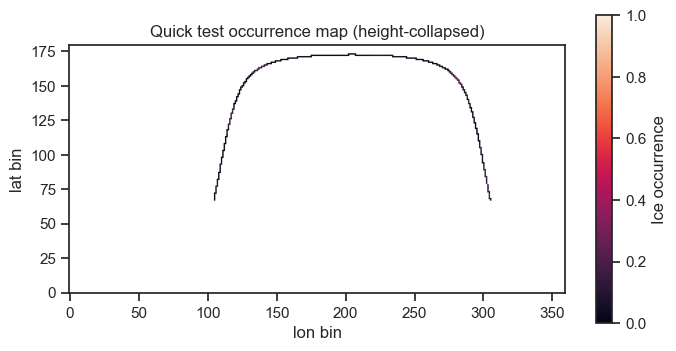

In [8]:

# Test a handful of ZIPs while cleaning local staged data after each ZIP
N_QUICK_TEST = min(5, len(zip_paths))

# Temporary 3D accumulators (same shape as full-run arrays)
total_test = np.zeros_like(total_count_3d)
ice_test = np.zeros_like(ice_count_3d)
failed_test = []
processed_h5_test = 0

for src_zip in zip_paths[:N_QUICK_TEST]:
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)

        for fp in h5_files:
            # Process one file into per-cell total/ice counts
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            total_test += t3d
            ice_test += i3d
            processed_h5_test += 1
    except Exception as e:
        failed_test.append((str(src_zip), str(e)))
    finally:
        cleanup_staged_data(local_zip, extract_dir)

print(f"Tested ZIPs: {N_QUICK_TEST}")
print(f"Processed H5 (test): {processed_h5_test}")
print(f"Failed ZIPs (test): {len(failed_test)}")
print("Total valid pixels (3D sum):", int(np.nansum(total_test)))
print("Total ice pixels (3D sum):", int(np.nansum(ice_test)))
print("3D shape:", total_test.shape)

nonzero_cells_3d = np.count_nonzero(total_test)
print("3D cells with data:", int(nonzero_cells_3d), "of", total_test.size)

if np.nansum(total_test) > 0:
    print("Overall ice occurrence (test):", float(np.nansum(ice_test) / np.nansum(total_test)))

if failed_test:
    print("\nFirst failure:")
    print(" - zip:", failed_test[0][0])
    print(" - error:", failed_test[0][1])

### QUICK LOOK ###

# collapse 3D -> 2D for quick look
num2d = np.nansum(ice_test, axis=2)
den2d = np.nansum(total_test, axis=2)
occ2d = np.divide(num2d, den2d, out=np.full_like(num2d, np.nan), where=den2d > 0)

plt.figure(figsize=(8, 4))
plt.imshow(occ2d, origin="lower", vmin=0, vmax=1)
plt.colorbar(label="Ice occurrence")
plt.title("Quick test occurrence map (height-collapsed)")
plt.xlabel("lon bin")
plt.ylabel("lat bin")
plt.show()


**7. Full Batch Processing**

In [9]:

# Stream all ZIPs from remote archive into local temp stage, process, and cleanup
# This mirrors check_run.py behavior but feeds your notebook accumulators.

total_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)
ice_count_3d = np.zeros((n_lat, n_lon, n_height), dtype=np.float64)

failed_zips = []
processed_h5 = 0
n_zips = len(zip_paths)

for idx, src_zip in enumerate(zip_paths, start=1):
    local_zip = None
    extract_dir = None
    try:
        local_zip, extract_dir, h5_files = stage_zip_and_extract(src_zip, LOCAL_STAGE_ROOT)

        for fp in h5_files:
            # Convert one file into 3D total/ice histograms
            t3d, i3d = accumulate_one_file(fp, lat_bins, lon_bins, target_h)
            # Add per-file contribution into global totals
            total_count_3d += t3d
            ice_count_3d += i3d
            processed_h5 += 1

    except Exception as e:
        failed_zips.append((str(src_zip), str(e)))

    finally:
        # Always clean local temp files to save disk space
        cleanup_staged_data(local_zip, extract_dir)

    # Progress update every 10 ZIPs (and at end)
    if idx % 10 == 0 or idx == n_zips:
        print(f"Processed ZIPs: {idx}/{n_zips} | processed_h5={processed_h5} | failed_zips={len(failed_zips)}")

print("Batch done")
print("ZIPs processed:", n_zips)
print("H5 files processed:", processed_h5)
print("ZIP failures:", len(failed_zips))
print("Total valid pixels (3D sum):", int(np.nansum(total_count_3d)))
print("Total ice pixels (3D sum):", int(np.nansum(ice_count_3d)))

"""
Every 1 deg x 1 deg cell will probably have to some extent ice clouds present.
So the best way to show where ice clouds are more common is to show the occurrence (fraction of valid pixels that are ice)
rather than absolute counts or binary yes/no. Absolute counts would be dominated by the sampling pattern and not reveal the underlying physical distribution as well.

Global occurrence = total ice / total valid
"""
if np.nansum(total_count_3d) > 0:
    print("Overall ice occurrence:", float(np.nansum(ice_count_3d) / np.nansum(total_count_3d)))

if failed_zips:
    print("\nFirst 3 ZIP failures:")
    for z, err in failed_zips[:3]:
        print(" -", z)
        print("   ", err)


Processed 10/17 files
Processed 17/17 files
Batch done
Files processed: 17
Files failed: 0
Total valid pixels (3D sum): 19925333
Total ice pixels (3D sum): 1125782
Overall ice occurrence: 0.056500034403440084


**8. Occurrence Map**

In [10]:
# Per-height occurrence in each (lat, lon, height) cell
# Value range: 0..1, NaN where no valid samples
occurrence_3d = np.divide(
    ice_count_3d,
    total_count_3d,
    out=np.full_like(ice_count_3d, np.nan, dtype=np.float64),
    where=total_count_3d > 0
)

# Collapse height axis to get a 2D map (lat, lon)
ice_2d = np.nansum(ice_count_3d, axis=2)
tot_2d = np.nansum(total_count_3d, axis=2)

# collapse longitude
ice_2d_height = np.nansum(ice_2d, axis=1)
tot_2d_height = np.nansum(tot_2d, axis=1)

# Height-collapsed occurrence map
occurrence_2d = np.divide(
    ice_2d,
    tot_2d,
    out=np.full_like(ice_2d, np.nan, dtype=np.float64),
    where=tot_2d > 0
)

# Optional: hide low-sample cells to reduce noisy/unstable ratios
if MIN_SAMPLES_PER_CELL is not None and MIN_SAMPLES_PER_CELL > 0:
    occurrence_2d[tot_2d < MIN_SAMPLES_PER_CELL] = np.nan

print("Occurrence computed")
print("3D shape:", occurrence_3d.shape)
print("2D shape:", occurrence_2d.shape)
print("Global occurrence:", float(np.nansum(ice_count_3d) / np.nansum(total_count_3d)) if np.nansum(total_count_3d) > 0 else np.nan)

Occurrence computed
3D shape: (180, 360, 242)
2D shape: (180, 360)
Global occurrence: 0.056500034403440084


**9. Save to NETCDF**

In [11]:
# Output subfolder per run window (keeps runs separated and reproducible)
outdir = f"{OUTPUT_ROOT}/{start_dt:%Y%m%d}_{end_dt:%Y%m%d}"
os.makedirs(outdir, exist_ok=True)

# File 1: 2D counts (summed over height)
outfile_counts = (
    f"{outdir}/regridded_satellite_icecloud"
    f"_counts_{GRID_RES_DEG}deg_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}.nc"
)

# File 2: 2D occurrence map (ice_count / total_count)
outfile_occurrence = (
    f"{outdir}/regridded_satellite_icecloud"
    f"_occurrence_{GRID_RES_DEG}deg_{start_dt:%Y%m%d}_{end_dt:%Y%m%d}.nc"
)

# Derive 2D counts from 3D accumulators by summing across height axis
ice_2d = np.nansum(ice_count_3d, axis=2)
tot_2d = np.nansum(total_count_3d, axis=2)

# Save counts dataset
xr.Dataset(
    {
        "total_count": (["latitude", "longitude"], tot_2d),
        "ice_count": (["latitude", "longitude"], ice_2d),
    },
    coords={
        "latitude": lat_centers,
        "longitude": lon_centers,
    }
).to_netcdf(outfile_counts)

# Save occurrence dataset
xr.Dataset(
    {
        "occurrence": (["latitude", "longitude"], occurrence_2d),
    },
    coords={
        "latitude": lat_centers,
        "longitude": lon_centers,
    }
).to_netcdf(outfile_occurrence)

print("Saved BOTH files:")
print(" →", outfile_counts)
print(" →", outfile_occurrence) 

Saved BOTH files:
 → /Users/tobiasraucher/Python/KNMI/Plot software/ectools/Final_Heatmap_IceClouds/output/20251201_20271231/regridded_satellite_icecloud_counts_1.0deg_20251201_20271231.nc
 → /Users/tobiasraucher/Python/KNMI/Plot software/ectools/Final_Heatmap_IceClouds/output/20251201_20271231/regridded_satellite_icecloud_occurrence_1.0deg_20251201_20271231.nc
